In [ ]:
%load_ext autoreload
%autoreload 2

# for src folder access
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import os
from matplotlib import pyplot as plt

from src.config import Config, DEFAULT_DATA_ROOT, TRIMMED_DATA_ROOT, default_session_to_activity
from src.preprocessing.clap_sync import accel_mag_from_df
from src.preprocessing.io_ax6 import find_session_file, load_ax6_csv, resample_to_fs

DEFAULT_DATA_ROOT

'C:\\Users\\blue_\\Desktop\\git-repos\\HAR_Projekt\\ax6_cnn_project\\data\\raw'

### Load data

In [3]:
data_paths = [
    [
        find_session_file(DEFAULT_DATA_ROOT, Config.left_id, s), 
        find_session_file(DEFAULT_DATA_ROOT, Config.right_id, s)
    ] for s in range(12, 22)
]

dfs = [
    [
        resample_to_fs(load_ax6_csv(left), Config.fs), 
        resample_to_fs(load_ax6_csv(right), Config.fs)
    ] for left, right in data_paths]

dfs[0][0]

,t,ax,ay,az,gx,gy,gz
0,0.00,0.274414,-0.134521,-1.105713,81.993095,74.516296,46.974178
1,0.01,0.375000,-0.751221,-0.519287,222.267136,-125.480644,-25.108335
2,0.02,0.552734,-1.099609,-0.630615,247.619614,-113.739006,2.098083
3,0.03,0.597656,-1.294678,-0.699707,249.992355,-110.122673,9.918213
4,0.04,0.598877,-1.413818,-0.758545,249.992355,-109.657280,22.705076
...,...,...,...,...,...,...,...
22714,227.14,-0.250977,0.814697,-0.671875,13.954162,-22.499083,-35.476685
22715,227.15,-0.260742,0.810791,-0.704102,0.885010,-32.714844,-20.080564
22716,227.16,-0.286377,0.848877,-0.735107,-9.521484,-39.505005,-3.112793
22717,227.17,-0.124512,0.528320,-0.745361,15.228271,8.583069,1.655578


### Calculate acceloration magnitude

In [4]:
for dfL, dfR in dfs:
    dfL["acc_mag"] = accel_mag_from_df(dfL)
    dfR["acc_mag"] = accel_mag_from_df(dfR)

In [5]:
# interactive plot
%matplotlib widget

from typing import Tuple
import pandas as pd


class InteractiveCutter:
    def __init__(self, dfL, dfR, exercise_id, figsize=(15, 3)):
        """Interactive plot using pyplot for manually removing excess data 

        Args:
            dfL (pandas.DataFrame): DataFrame from left sensor
            dfR (pandas.DataFrame): DataFrame from right sensor
            exercise_id (str): Plot label (just decorative)
            figsize (tuple, optional): (width, height). Defaults to (15, 3).
        """
        self.active_line = None  # currently picked lines
        self.dfL = dfL
        self.dfR = dfR
        
        self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=figsize)
        
        # plot
        self.dfL["acc_mag"].plot(ax=self.ax1, label="Left Sensor")
        self.dfR["acc_mag"].plot(ax=self.ax2, label="Right Sensor")
        
        # calc initial vlines indices
        idx_min = self.dfL.index.min()
        idx_max = self.dfL.index.max()
        width = (idx_max - idx_min) * 0.2
        p1, p2 = idx_min + 100, idx_min + 100 + width  # same for dfL and dfR
        
        self.lines = [
            self.ax1.axvline(p1, color='red', linestyle='--', lw=3, picker=5),
            self.ax1.axvline(p2, color='red', linestyle='--', lw=3, picker=5),
            self.ax2.axvline(p1, color='red', linestyle='--', lw=3, picker=5),
            self.ax2.axvline(p2, color='red', linestyle='--', lw=3, picker=5)
        ]
        
        # link callback methods
        self.fig.canvas.mpl_connect('pick_event', self._on_pick)
        self.fig.canvas.mpl_connect('motion_notify_event', self._on_motion)
        self.fig.canvas.mpl_connect('button_release_event', self._on_release)
        
        self.ax1.title.set_text(str(exercise_id))
        plt.tight_layout()
        plt.show()

    def _on_pick(self, event):
        if event.artist in self.lines:
            self.active_line = event.artist

    def _on_release(self, event):
        self.active_line = None

    def _on_motion(self, event):
        if self.active_line and event.xdata is not None:
            # get current positions
            l1, r1 = self.lines[0].get_xdata()[0], self.lines[1].get_xdata()[0]
            l2, r2 = self.lines[2].get_xdata()[0], self.lines[3].get_xdata()[0]
            
            # moved lines in first plot
            if self.active_line in self.lines[:2]:
                self.active_line.set_xdata([event.xdata, event.xdata])
                
                # calc distance of lines in first plot to ...
                new_width = abs(self.lines[1].get_xdata()[0] - self.lines[0].get_xdata()[0])
                
                # ... force same width in second plot
                self.lines[3].set_xdata([l2 + new_width, l2 + new_width])
            
            # moved lines in second plot
            elif self.active_line in self.lines[2:]:
                width_top = abs(r1 - l1)
                if self.active_line == self.lines[2]:   # left line picked -> move right line to keep same width
                    self.lines[2].set_xdata([event.xdata, event.xdata])
                    self.lines[3].set_xdata([event.xdata + width_top, event.xdata + width_top])
                else:                                   # right line picked -> move left line too
                    self.lines[3].set_xdata([event.xdata, event.xdata])
                    self.lines[2].set_xdata([event.xdata - width_top, event.xdata - width_top])
            
            self.fig.canvas.draw_idle()

    def get_data(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """Extracts data between set lines and create new DataFrames

        Returns:
            Tuple[pd.DataFrame, pd.DataFrame]: dfL_cut, dfR_cut
        """
        lim_L = sorted([self.lines[0].get_xdata()[0], self.lines[1].get_xdata()[0]])
        lim_R = sorted([self.lines[2].get_xdata()[0], self.lines[3].get_xdata()[0]])
        
        df_cut_L = self.dfL.loc[(self.dfL.index >= lim_L[0]) & (self.dfL.index <= lim_L[1])].copy()
        df_cut_R = self.dfR.loc[(self.dfR.index >= lim_R[0]) & (self.dfR.index <= lim_R[1])].copy()
        
        return df_cut_L, df_cut_R

### Trim manually

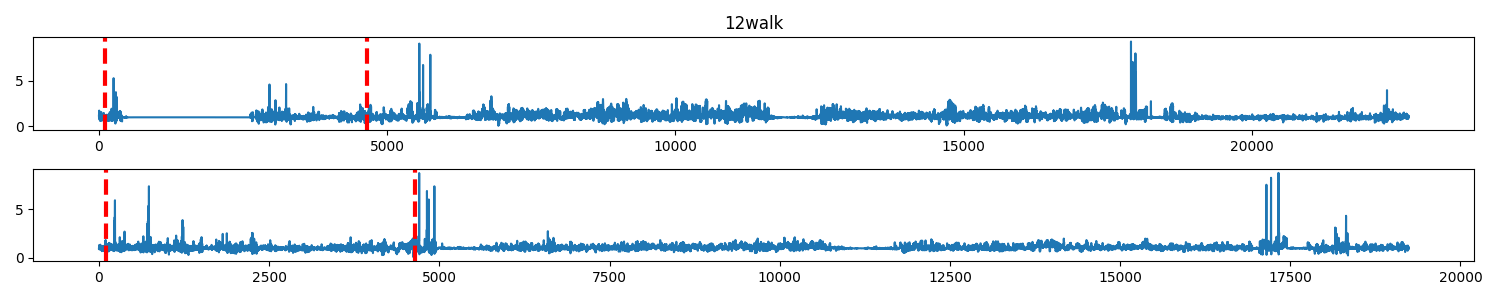

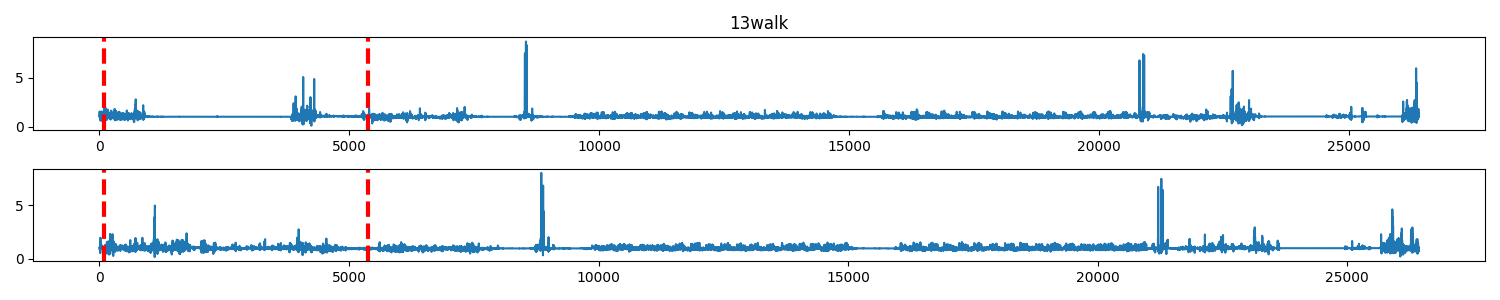

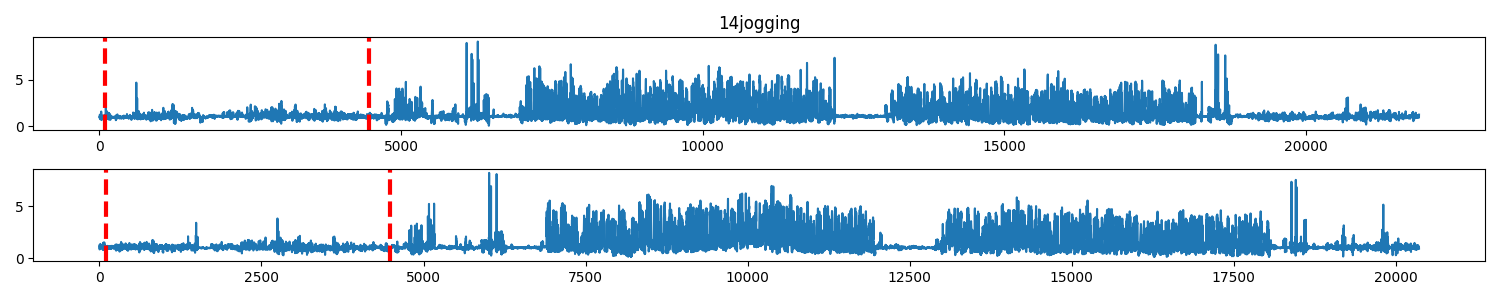

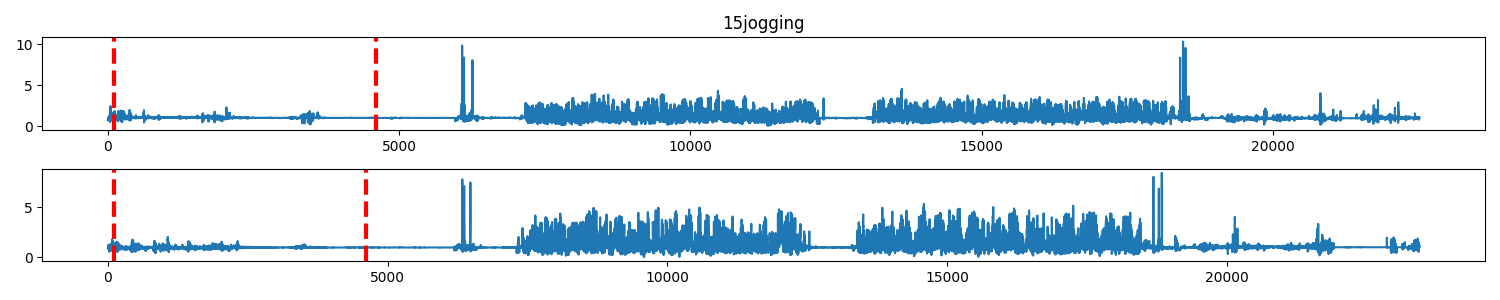

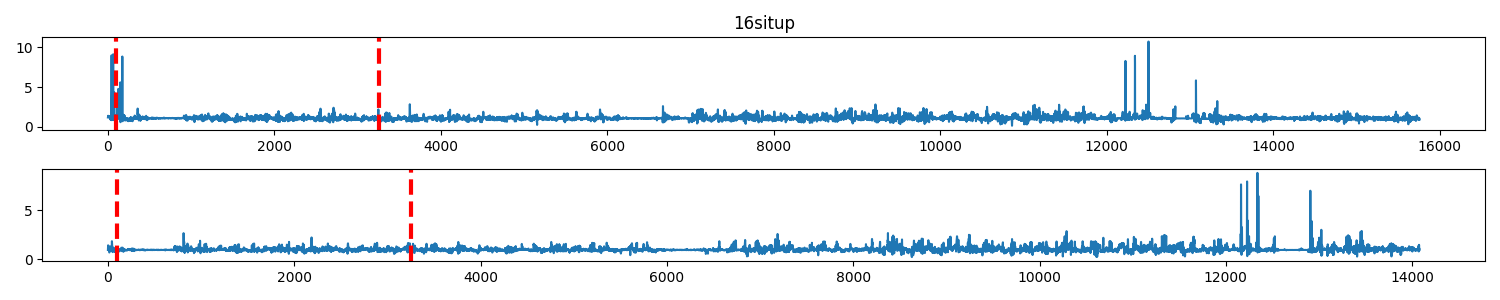

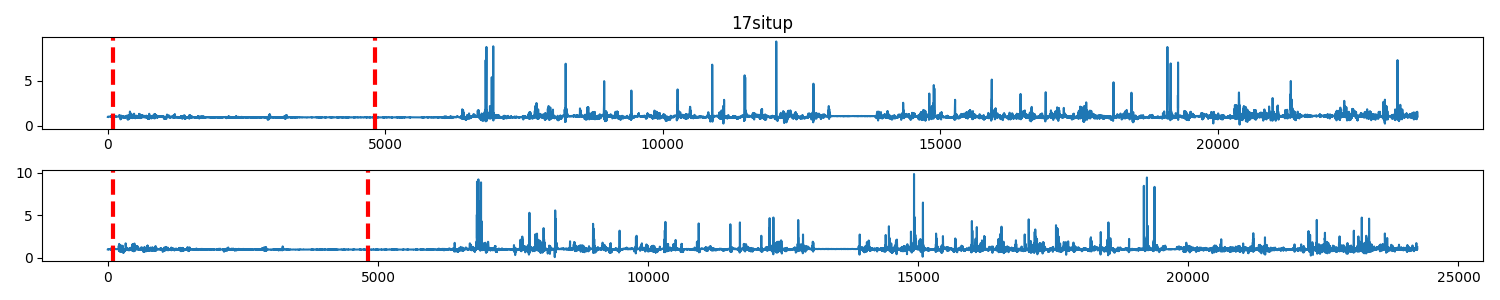

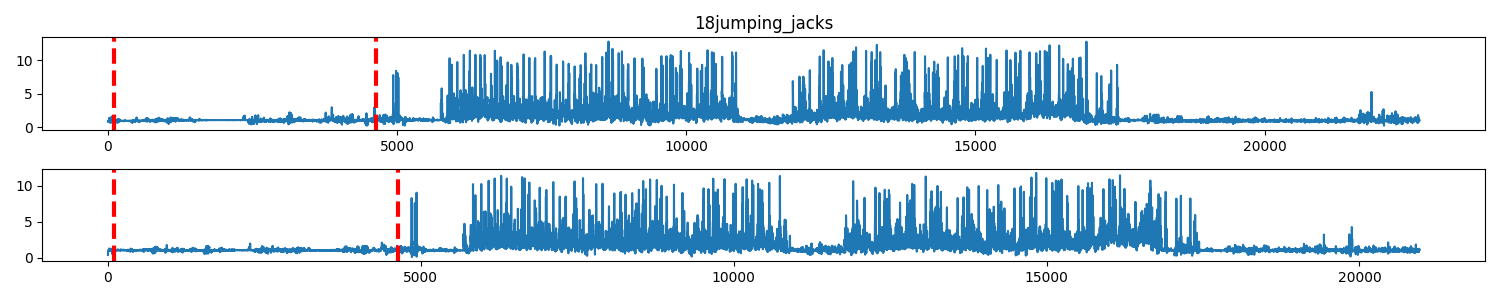

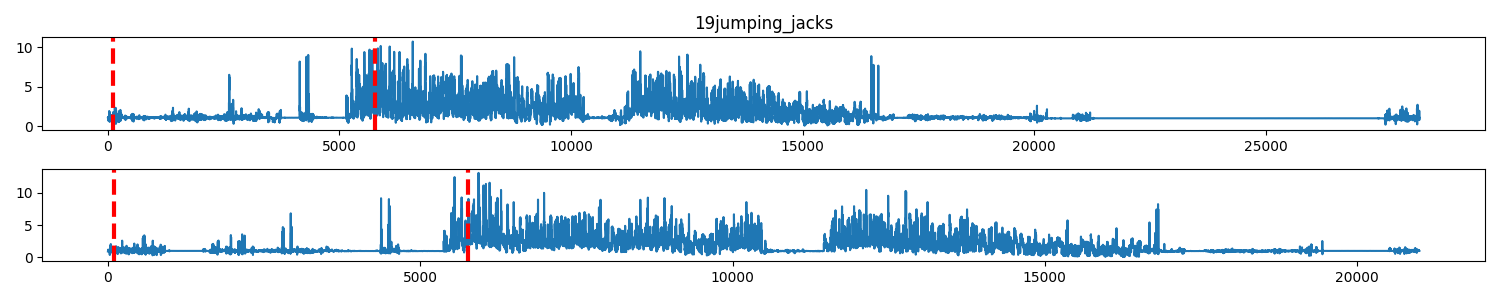

C:\Users\blue_\AppData\Local\Temp\ipykernel_13912\2926842687.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=figsize)


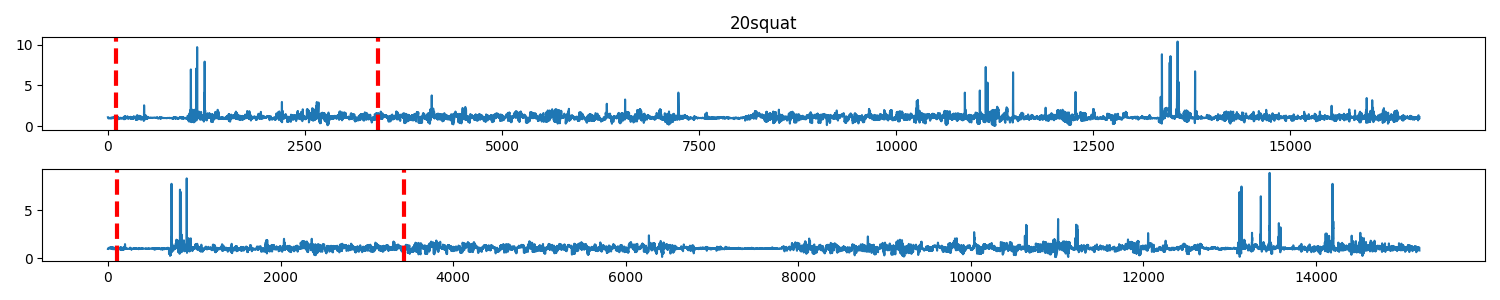

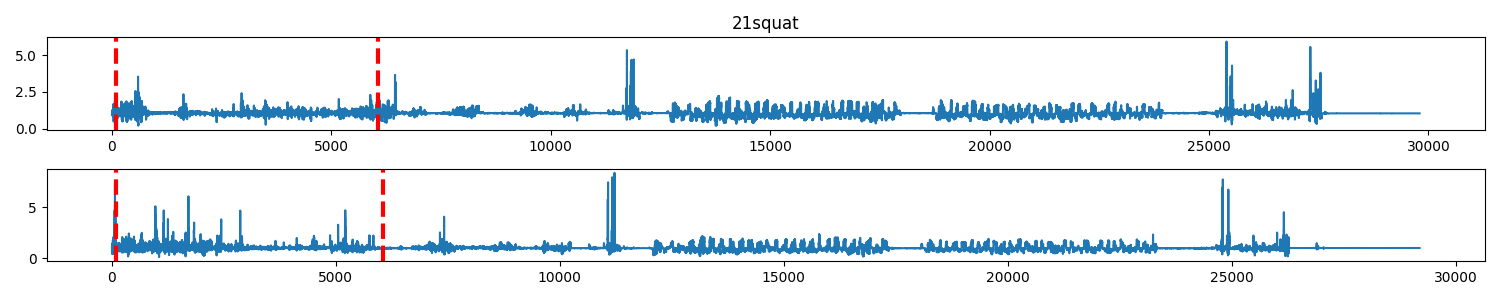

In [ ]:
cutters = [InteractiveCutter(dfL, dfR, str(id)+default_session_to_activity()[id]) for id, (dfL, dfR) in enumerate(dfs, start=12)]

### Result example (interactive plots wont be saved when juypter server restarts)

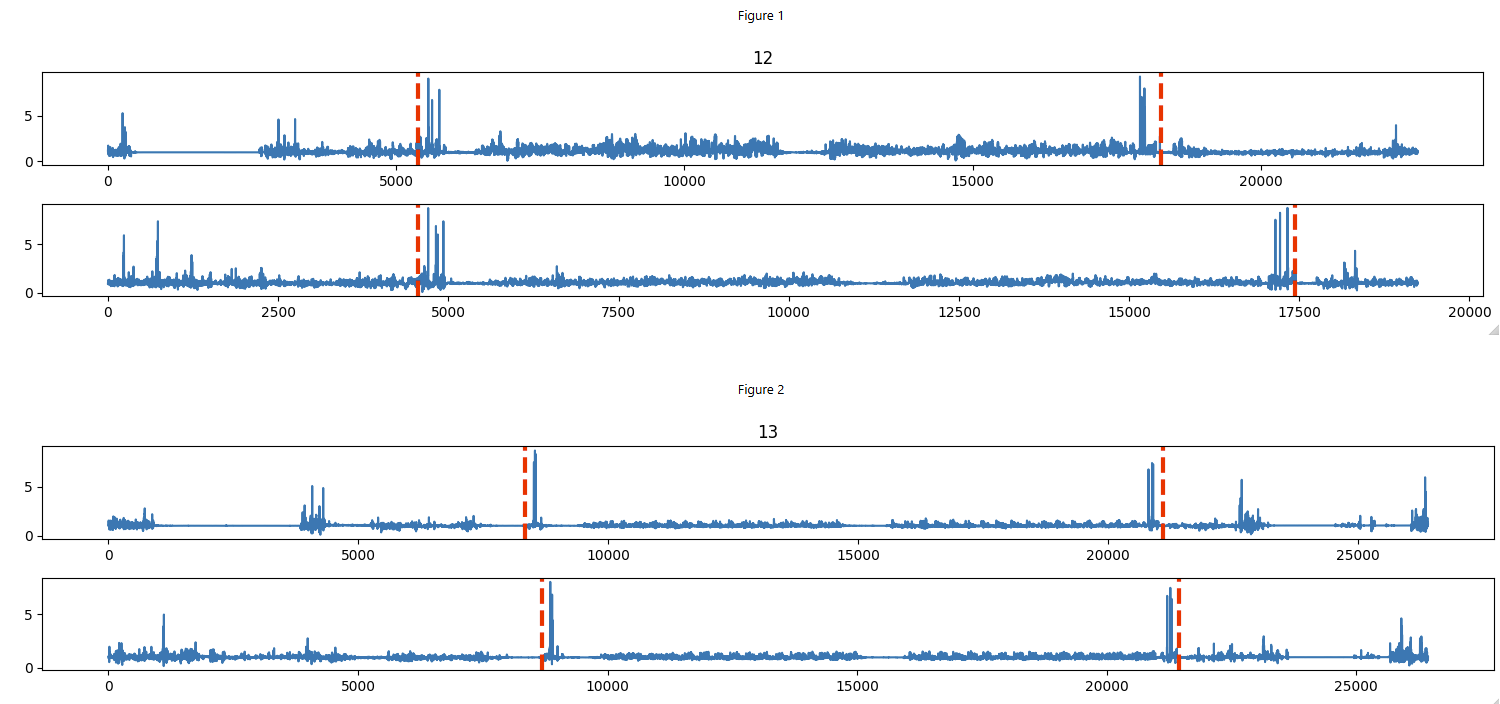

In [10]:
from IPython.display import Image
Image(filename="example_trim.png")

### Show first 6 seconds (later used for synchronisation)

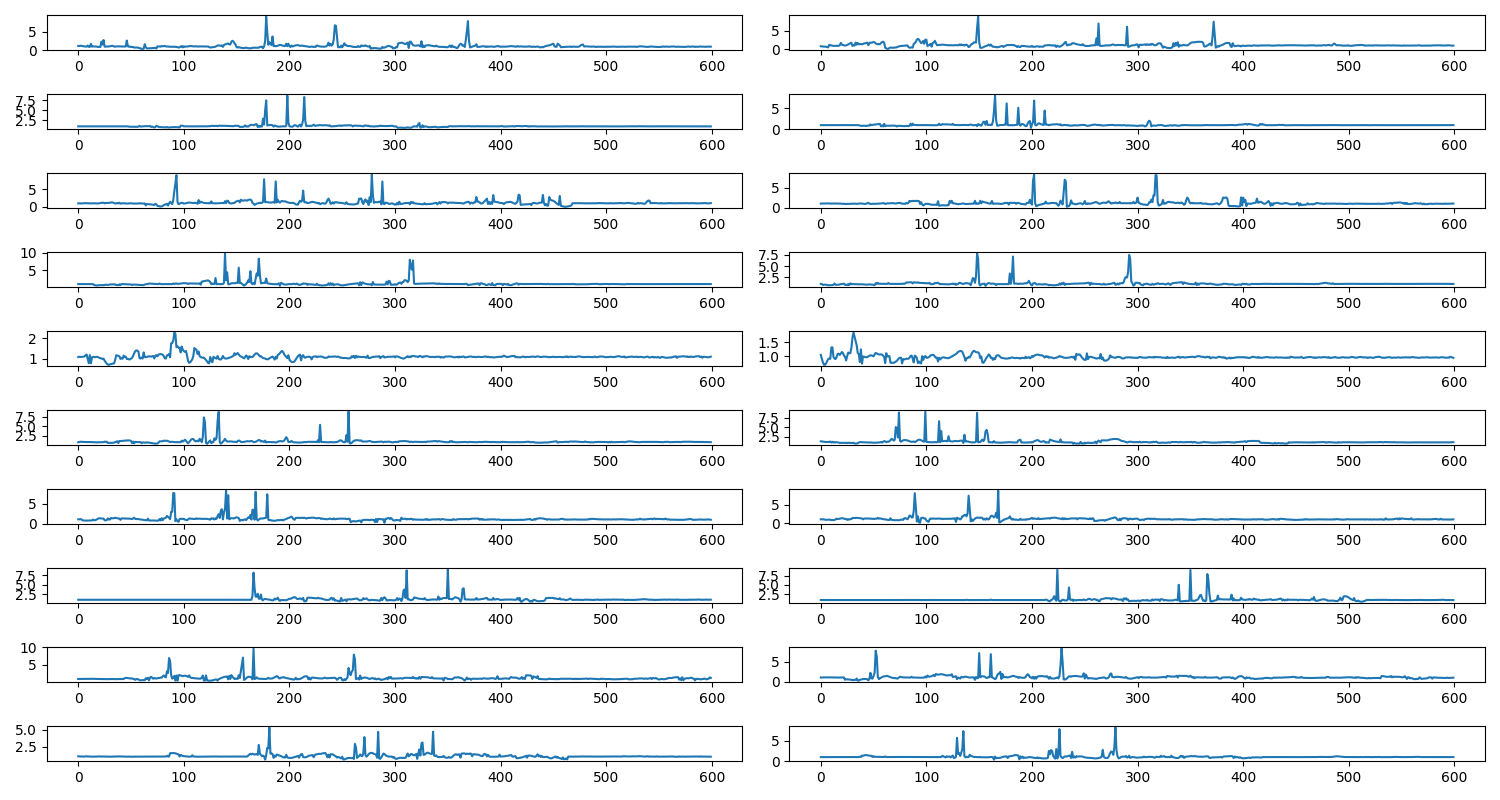

In [11]:
trimmed_dfs = [c.get_data() for c in cutters]

fig, ax = plt.subplots(10, 2, figsize=(15, 8))
for (ax1, ax2), (dfL, dfR) in zip(ax, trimmed_dfs):
    ax1.plot(accel_mag_from_df(dfL)[:600])
    ax2.plot(accel_mag_from_df(dfR)[:600])
plt.tight_layout()

### Save the files

In [12]:
if not os.path.exists(TRIMMED_DATA_ROOT):
    os.mkdir(TRIMMED_DATA_ROOT)
    
for (dfL, dfR), id in zip(trimmed_dfs, range(12, 22)):
    _path = os.path.join(TRIMMED_DATA_ROOT, str(id))
    if _path + "left.csv" not in os.listdir(TRIMMED_DATA_ROOT):
        dfL.to_csv(_path + "left.csv", index=False)
        dfR.to_csv(_path + "right.csv", index=False)